<a href="https://colab.research.google.com/github/winwinjong-gif/Machin-Learning-report/blob/main/week3/car_mpg_regression_encoding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import LabelEncoder

In [4]:
df=pd.read_csv("/content/drive/MyDrive/기계학습프로그래밍/auto-mpg.data",sep=r"\s+",header=None)
df

,0,1,2,3,4,5,6,7,8
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.00,2790.0,15.6,82,1,ford mustang gl
394,44.0,4,97.0,52.00,2130.0,24.6,82,2,vw pickup
395,32.0,4,135.0,84.00,2295.0,11.6,82,1,dodge rampage
396,28.0,4,120.0,79.00,2625.0,18.6,82,1,ford ranger


In [5]:
df.columns=["mpg","cylinders","displacement","horsepower","weight","acceleration","model_year","origin","car_name"]
df

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.00,2790.0,15.6,82,1,ford mustang gl
394,44.0,4,97.0,52.00,2130.0,24.6,82,2,vw pickup
395,32.0,4,135.0,84.00,2295.0,11.6,82,1,dodge rampage
396,28.0,4,120.0,79.00,2625.0,18.6,82,1,ford ranger


In [6]:
label_encoders = {}

for column in df.columns:

    label_encoders[column] = LabelEncoder()

    df[column] = label_encoders[column].fit_transform(df[column])

X=df.drop(["car_name","mpg"],axis=1)
y=df["mpg"]
print(X)
print(y)

     cylinders  displacement  horsepower  weight  acceleration  model_year  \
0            4            69          15     247            13           0   
1            4            72          33     265            11           0   
2            4            70          27     241             6           0   
3            4            67          27     240            13           0   
4            4            66          22     244             5           0   
..         ...           ...         ...     ...           ...         ...   
393          1            41          80     160            43          12   
394          1            17          51      54            93          12   
395          1            40          78      89            12          12   
396          1            34          73     136            71          12   
397          1            33          76     152            76          12   

     origin  
0         0  
1         0  
2         0  
3      

In [9]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = DecisionTreeRegressor(random_state=42)
model.fit(X_train, y_train)
pred_dt = model.predict(X_test)

평균제곱오차(sklearn): 329.6375
평균제곱오차(NumPy): 329.6375
평균제곱오차(직접 계산): 329.6375


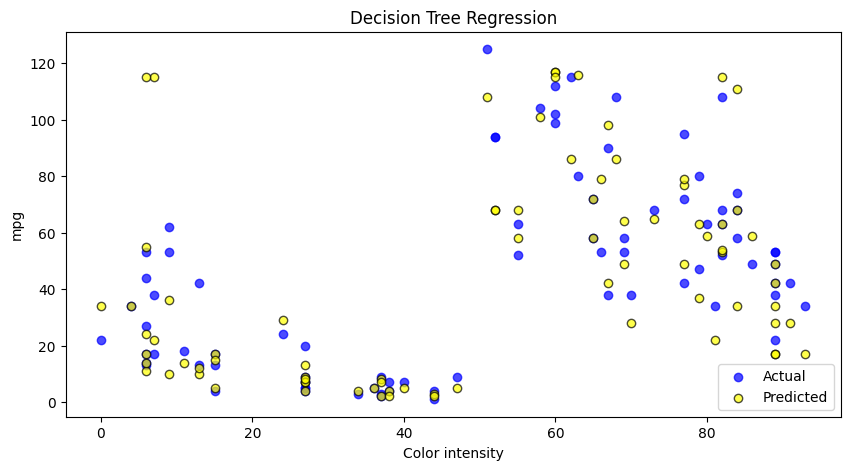

In [11]:
# MSE 계산: sklearn
print("평균제곱오차(sklearn):", mean_squared_error(y_test, pred_dt))

# MSE 계산: NumPy
def mse_np(actual, predicted):
    return np.mean((np.array(actual) - np.array(predicted)) ** 2)

print("평균제곱오차(NumPy):", mse_np(y_test, pred_dt))

# MSE 계산: 파이썬
def mse(actual, predicted):
    sum_square_error = sum(
        (a - p) ** 2 for a, p in zip(actual, predicted)
    )
    return sum_square_error / len(actual)

print("평균제곱오차(직접 계산):", mse(y_test, pred_dt))

# 실제 값과 예측값 비교
plt.figure(figsize=(10, 5))
plt.scatter(
    X_test["horsepower"], y_test,
    color="blue", label="Actual", alpha=0.7
)
plt.scatter(
    X_test["horsepower"], pred_dt,
    color="yellow", edgecolors="black", label="Predicted", alpha=0.7
)
plt.title("Decision Tree Regression")
plt.xlabel("Color intensity")
plt.ylabel("mpg")
plt.legend()
plt.show()

평균제곱오차(sklearn): 98.28607500000001
평균제곱오차(NumPy): 98.28607500000001
평균제곱오차(직접 계산): 98.286075


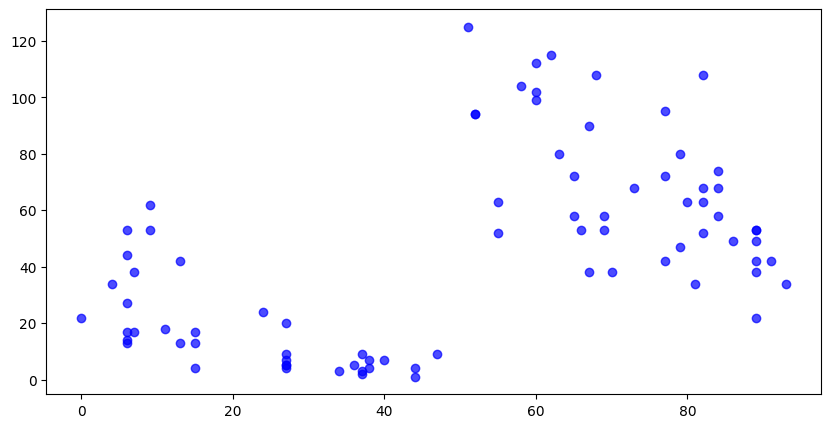

In [12]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

pred_rf = model.predict(X_test)

# MSE 계산: sklearn
print("평균제곱오차(sklearn):", mean_squared_error(y_test, pred_rf))

# MSE 계산: NumPy
def mse_np(actual, predicted):
    return np.mean((np.array(actual) - np.array(predicted)) ** 2)

print("평균제곱오차(NumPy):", mse_np(y_test, pred_rf))

# MSE 계산: 파이썬
def mse(actual, predicted):
    sum_square_error = sum(
        (a - p) ** 2 for a, p in zip(actual, predicted)
    )
    return sum_square_error / len(actual)

print("평균제곱오차(직접 계산):", mse(y_test, pred_rf))

# 실제 값과 예측값 비교
plt.figure(figsize=(10, 5))

plt.scatter(
    X_test["horsepower"], y_test,
    color="blue", label="Actual", alpha=0.7
)

평균제곱오차(sklearn): 146.5294186049501
평균제곱오차(NumPy): 146.5294186049501
평균제곱오차(직접 계산): 146.52941860495005


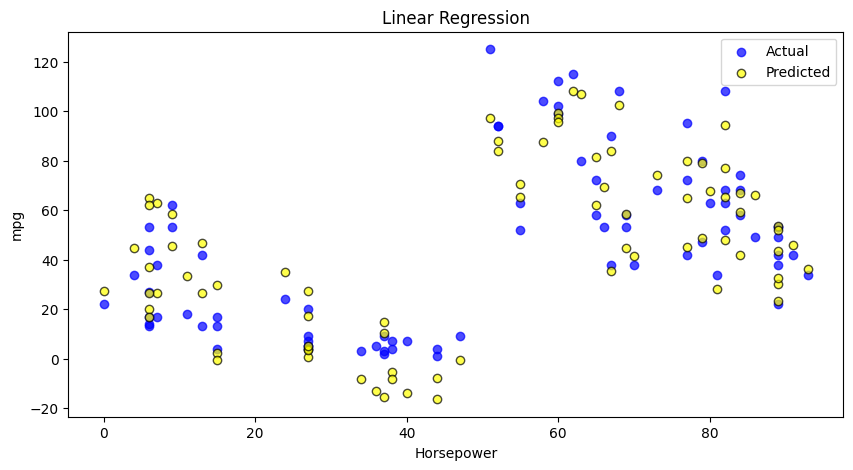

In [13]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

pred_lr = model.predict(X_test)

# MSE 계산: sklearn
print("평균제곱오차(sklearn):", mean_squared_error(y_test, pred_lr))

# MSE 계산: NumPy
def mse_np(actual, predicted):
    return np.mean((np.array(actual) - np.array(predicted)) ** 2)

print("평균제곱오차(NumPy):", mse_np(y_test, pred_lr))

# MSE 계산: 파이썬
def mse(actual, predicted):
    sum_square_error = sum(
        (a - p) ** 2 for a, p in zip(actual, predicted)
    )
    return sum_square_error / len(actual)

print("평균제곱오차(직접 계산):", mse(y_test, pred_lr))

# 실제 값과 예측값 비교
plt.figure(figsize=(10, 5))

plt.scatter(
    X_test["horsepower"], y_test,
    color="blue", label="Actual", alpha=0.7
)

plt.scatter(
    X_test["horsepower"], pred_lr,
    color="yellow", edgecolors="black",
    label="Predicted", alpha=0.7
)

plt.title("Linear Regression")
plt.xlabel("Horsepower")
plt.ylabel("mpg")
plt.legend()
plt.show()